In [1]:
#logistic regression with L2 regularization
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

In [2]:
HospData = pd.read_csv('hospital_readmission.csv')
print(HospData)

      age  num_diagnoses  prior_admissions  prior_ed_visits  length_of_stay  \
0    91.2              2                 0                1             1.0   
1    60.7              2                 1                1            10.6   
2    57.7              4                 1                1             1.2   
3    25.2              1                 2                0             7.2   
4    64.9              3                 0                4             3.4   
..    ...            ...               ...              ...             ...   
495  71.7              3                 1                1             6.6   
496  74.8              3                 0                0             1.5   
497  48.2              5                 2                4             6.9   
498  62.8              4                 1                2             2.6   
499  60.0              3                 1                0             2.9   

     num_medications  heart_rate  systolic_bp  gluc

In [3]:
# Select features and target
x = HospData.iloc[:, :10]   # first 10 columns as features
y = HospData.iloc[:, 10]    # last column (readmitted) as target

In [4]:
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=11
)

In [5]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)


LogisticRegression(max_iter=1000)

In [6]:
# Predictions
y_pred = logreg.predict(x_test)

In [8]:
y_pred_proba = logreg.predict_proba(x_test)[:, 1]

In [9]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

In [10]:
print("Test Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("ROC-AUC Score:", auc)
print(classification_report(y_test, y_pred))

Test Accuracy: 0.68
Confusion Matrix:
 [[65  3]
 [29  3]]
ROC-AUC Score: 0.703125
              precision    recall  f1-score   support

           0       0.69      0.96      0.80        68
           1       0.50      0.09      0.16        32

    accuracy                           0.68       100
   macro avg       0.60      0.52      0.48       100
weighted avg       0.63      0.68      0.60       100



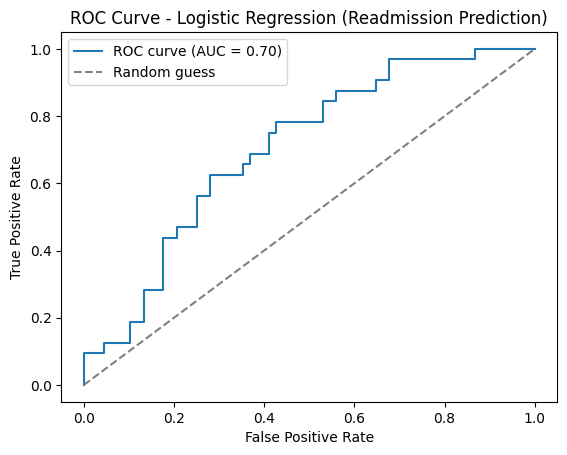

In [11]:
# ---- ROC curve plot ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Readmission Prediction)")
plt.legend()
plt.show()



In [12]:
# ---- Clinical cost discussion: False Negatives vs False Positives ----
tn, fp, fn, tp = cm.ravel()
print("\nTrue Negatives :", tn)
print("False Positives:", fp, " (flagged as high-risk but NOT readmitted -> extra follow-up call, low harm)")
print("False Negatives:", fn, " (missed a patient who WAS readmitted -> preventable harm + cost, high harm)")
print("True Positives :", tp)


True Negatives : 65
False Positives: 3  (flagged as high-risk but NOT readmitted -> extra follow-up call, low harm)
False Negatives: 29  (missed a patient who WAS readmitted -> preventable harm + cost, high harm)
True Positives : 3
